# 📈 Módulo 4: Técnicas de Regressão em Mineração de Dados


---

## 📋 Objetivos
- Implementar e comparar modelos de regressão: OLS, Ridge, LASSO, ElasticNet, Random Forest, XGBoost
- Realizar diagnóstico completo de resíduos
- Visualizar o caminho de regularização e o trade-off viés-variância
- Construir intervalos de predição com Predição Conformal

## 📑 Conteúdo
1. [Setup e Instalação](#setup)
2. [Dataset California Housing e EDA](#eda)
3. [Regressão Linear e Diagnóstico de Resíduos](#linear)
4. [Ridge, LASSO e ElasticNet Comparados](#regularization)
5. [Regressão Polinomial e Trade-off Viés-Variância](#poly)
6. [Random Forest para Regressão](#rf)
7. [XGBoost e LightGBM + SHAP](#xgb)
8. [Comparação Completa de Modelos](#comparison)
9. [Análise de Erros](#error-analysis)
10. [Predição com Intervalo de Confiança](#intervals)
11. [Exercícios](#exercises)


In [ ]:
# Instalação de dependências
!pip install -q xgboost lightgbm shap scikit-learn pandas numpy matplotlib seaborn scipy plotly mapie

## 📦 Setup
<a id='setup'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)

# XGBoost e LightGBM
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# SHAP
import shap

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Configuração visual
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3
})
sns.set_theme(style='whitegrid', palette='muted')

# Função auxiliar para calcular todas as métricas de regressão
def regression_metrics(y_true, y_pred, nome='Modelo'):
    """Retorna dicionário com MSE, RMSE, MAE, MAPE e R²."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    try:
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    except:
        mape = np.nan
    return {'Modelo': nome, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE(%)': mape, 'R2': r2}

print('Bibliotecas carregadas com sucesso!')
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__}')

Bibliotecas carregadas com sucesso!
NumPy: 1.26.4 | Pandas: 2.3.3


## 🏠 1. Dataset: California Housing
<a id='eda'></a>

O dataset **California Housing** contém informações sobre distritos da Califórnia (censo 1990). Objetivo: prever o **valor mediano das casas** (em 100k USD).

In [2]:
# ── Carregamento e EDA ────────────────────────────────────────────────────────
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # Valor mediano em 100k USD

print('=' * 55)
print('  California Housing — Resumo')
print('=' * 55)
print(f'  Amostras:  {df.shape[0]:,}')
print(f'  Features:  {df.shape[1] - 1}')
print(f'  Target:    MedHouseVal (valor mediano das casas em 100k USD)')
print()
print('Descrição das Features:')
feature_desc = {
    'MedInc':     'Renda mediana do bloco (10k USD)',
    'HouseAge':   'Idade mediana das casas',
    'AveRooms':   'Média de cômodos por domicílio',
    'AveBedrms':  'Média de quartos por domicílio',
    'Population': 'População do bloco',
    'AveOccup':   'Ocupantes médios por domicílio',
    'Latitude':   'Latitude',
    'Longitude':  'Longitude'
}
for feat, desc in feature_desc.items():
    print(f'  {feat:<12}: {desc}')

print()
print(df.describe().round(2).to_string())

  California Housing — Resumo
  Amostras:  20,640
  Features:  8
  Target:    MedHouseVal (valor mediano das casas em 100k USD)

Descrição das Features:
  MedInc      : Renda mediana do bloco (10k USD)
  HouseAge    : Idade mediana das casas
  AveRooms    : Média de cômodos por domicílio
  AveBedrms   : Média de quartos por domicílio
  Population  : População do bloco
  AveOccup    : Ocupantes médios por domicílio
  Latitude    : Latitude
  Longitude   : Longitude

         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00  20640.00   20640.00     20640.00
mean       3.87     28.64      5.43       1.10     1425.48      3.07     35.63    -119.57         2.07
std        1.90     12.59      2.47       0.47     1132.46     10.39      2.14       2.00         1.15
min        0.50      1.00      0.85       0.33        3.00      0.69     32.54    -124.35         0.15
25%        2.56

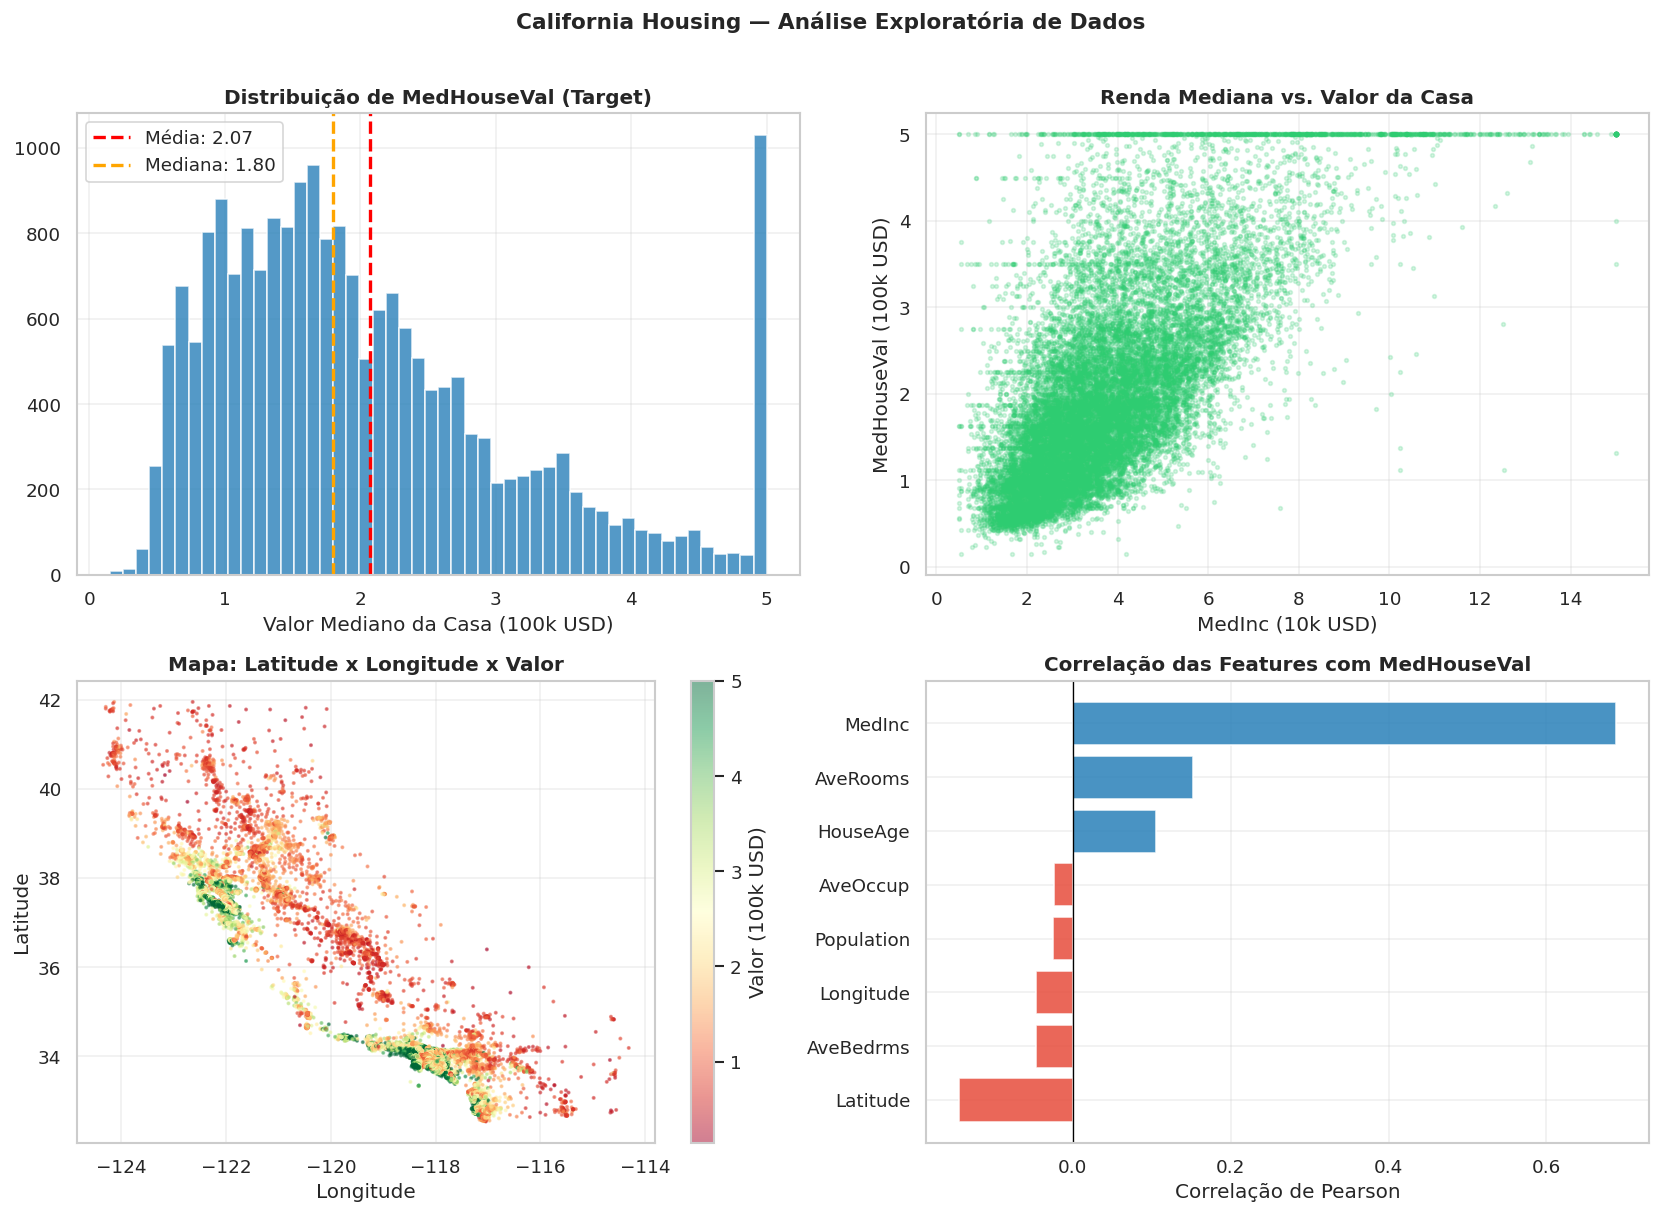

In [3]:
# ── EDA Visual ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribuição do target
axes[0, 0].hist(df['MedHouseVal'], bins=50, color='#2980b9', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(df['MedHouseVal'].mean(), color='red', lw=2, ls='--', label=f'Média: {df["MedHouseVal"].mean():.2f}')
axes[0, 0].axvline(df['MedHouseVal'].median(), color='orange', lw=2, ls='--', label=f'Mediana: {df["MedHouseVal"].median():.2f}')
axes[0, 0].set_title('Distribuição de MedHouseVal (Target)', fontweight='bold')
axes[0, 0].set_xlabel('Valor Mediano da Casa (100k USD)')
axes[0, 0].legend()

# Scatter: MedInc vs. Target
axes[0, 1].scatter(df['MedInc'], df['MedHouseVal'], alpha=0.2, s=5, c='#2ecc71')
axes[0, 1].set_title('Renda Mediana vs. Valor da Casa', fontweight='bold')
axes[0, 1].set_xlabel('MedInc (10k USD)')
axes[0, 1].set_ylabel('MedHouseVal (100k USD)')

# Mapa geográfico (Latitude x Longitude colorido pelo target)
sc = axes[1, 0].scatter(
    df['Longitude'], df['Latitude'],
    c=df['MedHouseVal'], cmap='RdYlGn',
    alpha=0.5, s=2
)
plt.colorbar(sc, ax=axes[1, 0], label='Valor (100k USD)')
axes[1, 0].set_title('Mapa: Latitude x Longitude x Valor', fontweight='bold')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# Correlação com o target
corr_with_target = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
colors_corr = ['#e74c3c' if v < 0 else '#2980b9' for v in corr_with_target]
axes[1, 1].barh(corr_with_target.index, corr_with_target.values, color=colors_corr, edgecolor='white', alpha=0.85)
axes[1, 1].axvline(0, color='black', lw=0.8)
axes[1, 1].set_title('Correlação das Features com MedHouseVal', fontweight='bold')
axes[1, 1].set_xlabel('Correlação de Pearson')

plt.suptitle('California Housing — Análise Exploratória de Dados', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 📏 2. Regressão Linear e Diagnóstico
<a id='linear'></a>

Treino: (16512, 8) | Teste: (4128, 8)

Métricas — Regressão Linear:
  MSE: 0.5559
  RMSE: 0.7456
  MAE: 0.5332
  MAPE(%): 31.9522
  R2: 0.5758

Coeficientes (dados normalizados):
   Feature  Coeficiente
  Latitude    -0.896929
 Longitude    -0.869842
  AveRooms    -0.294410
  AveOccup    -0.040829
Population    -0.002308
  HouseAge     0.122546
 AveBedrms     0.339259
    MedInc     0.854383


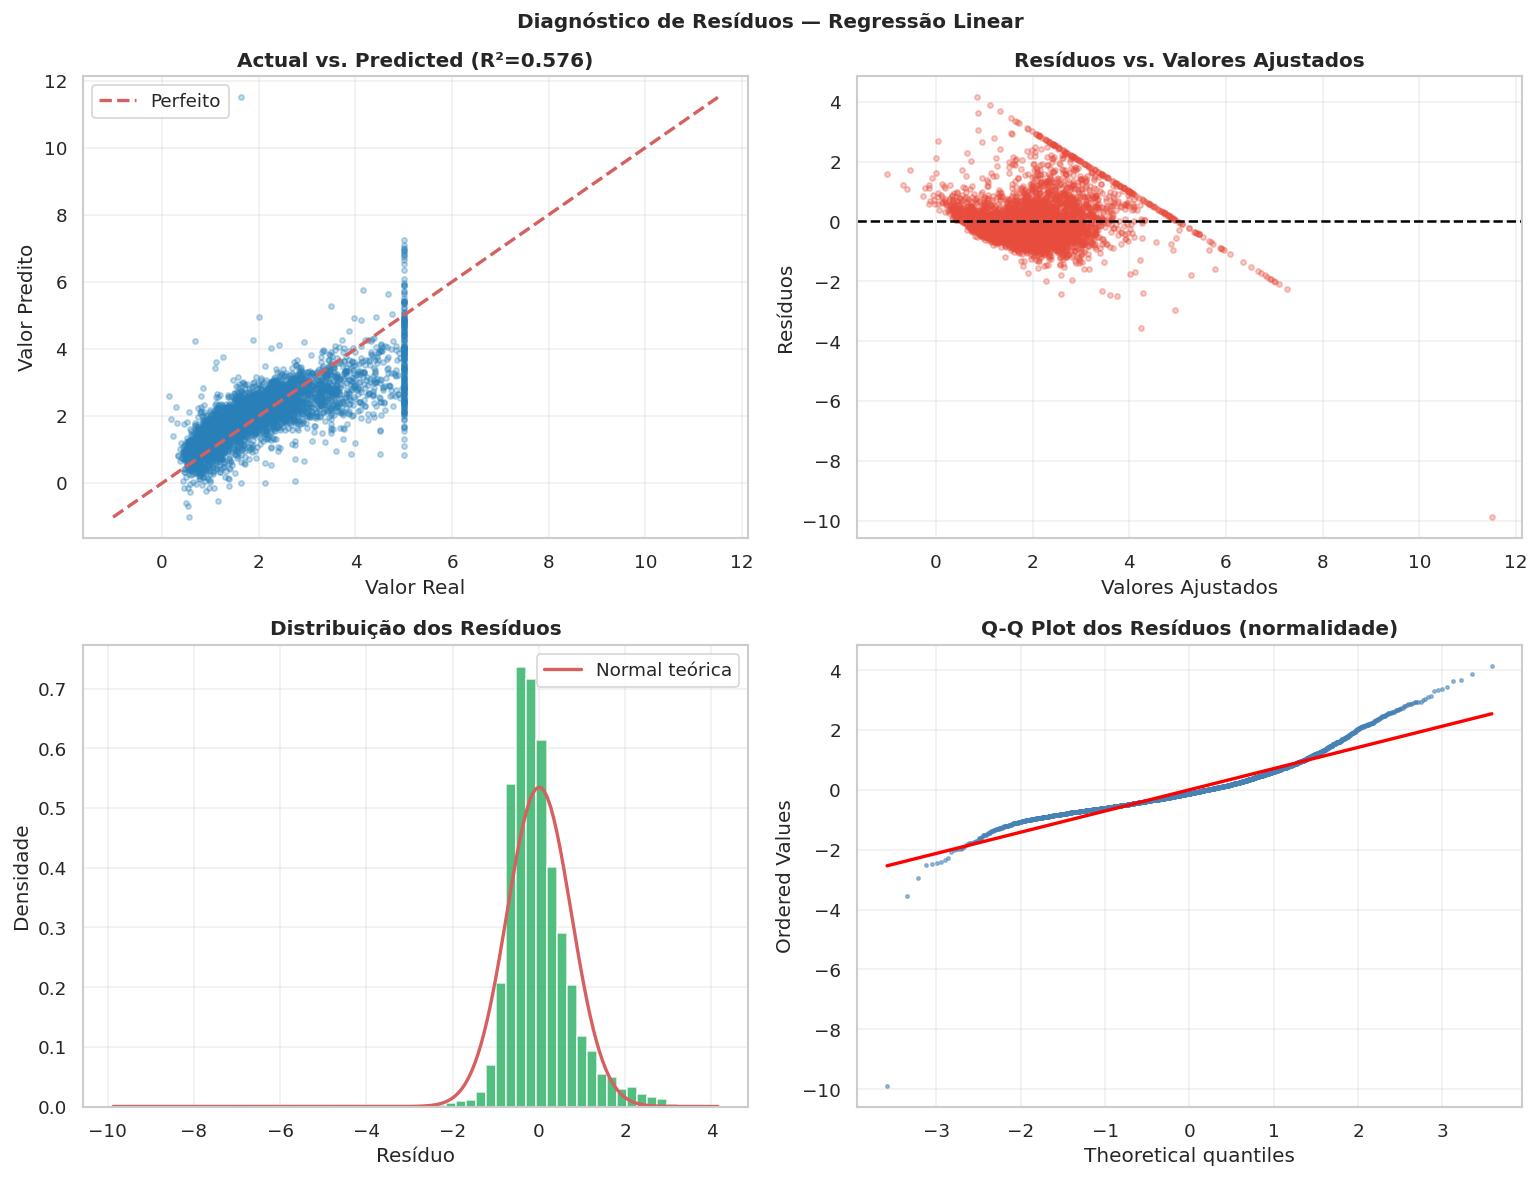


Testes Estatísticos sobre os Resíduos:
  Shapiro-Wilk (normalidade): W=0.9325, p=0.0000 → NÃO-NORMAL
  Durbin-Watson: DW=2.0407 → OK


In [4]:
# ── Divisão Treino / Teste ────────────────────────────────────────────────────
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

# Normalização
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Regressão Linear com Diagnóstico ────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
y_pred_train_lr = lr.predict(X_train_sc)

metrics_lr = regression_metrics(y_test, y_pred_lr, 'Linear Regression')
print('\nMétricas — Regressão Linear:')
for k, v in metrics_lr.items():
    if k != 'Modelo':
        print(f'  {k}: {v:.4f}')

# Coeficientes
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': lr.coef_
}).sort_values('Coeficiente')
print('\nCoeficientes (dados normalizados):')
print(coef_df.to_string(index=False))

# ── Gráficos de Diagnóstico de Resíduos ─────────────────────────────────────
residuals = y_test - y_pred_lr

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_lr, alpha=0.3, s=10, c='#2980b9')
min_val, max_val = min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfeito')
axes[0, 0].set_xlabel('Valor Real')
axes[0, 0].set_ylabel('Valor Predito')
axes[0, 0].set_title(f'Actual vs. Predicted (R²={metrics_lr["R2"]:.3f})', fontweight='bold')
axes[0, 0].legend()

# 2. Resíduos vs. Ajustados
axes[0, 1].scatter(y_pred_lr, residuals, alpha=0.3, s=10, c='#e74c3c')
axes[0, 1].axhline(0, color='black', lw=1.5, ls='--')
axes[0, 1].set_xlabel('Valores Ajustados')
axes[0, 1].set_ylabel('Resíduos')
axes[0, 1].set_title('Resíduos vs. Valores Ajustados', fontweight='bold')

# 3. Histograma dos resíduos
axes[1, 0].hist(residuals, bins=60, color='#27ae60', edgecolor='white', alpha=0.8, density=True)
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
axes[1, 0].plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
                'r-', lw=2, label='Normal teórica')
axes[1, 0].set_xlabel('Resíduo')
axes[1, 0].set_ylabel('Densidade')
axes[1, 0].set_title('Distribuição dos Resíduos', fontweight='bold')
axes[1, 0].legend()

# 4. Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot dos Resíduos (normalidade)', fontweight='bold')
axes[1, 1].get_lines()[0].set(color='steelblue', markersize=2, alpha=0.5)
axes[1, 1].get_lines()[1].set(color='red', lw=2)

plt.suptitle('Diagnóstico de Resíduos — Regressão Linear', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Testes estatísticos
print('\nTestes Estatísticos sobre os Resíduos:')
stat_sw, p_sw = stats.shapiro(residuals[:500])  # Shapiro-Wilk (limite n=5000)
print(f'  Shapiro-Wilk (normalidade): W={stat_sw:.4f}, p={p_sw:.4f} → {"NORMAL" if p_sw > 0.05 else "NÃO-NORMAL"}')
# DW simplificado
dw = np.sum(np.diff(residuals.values)**2) / np.sum(residuals.values**2)
print(f'  Durbin-Watson: DW={dw:.4f} → {"OK" if 1.5 < dw < 2.5 else "Autocorrelação detectada!"}')

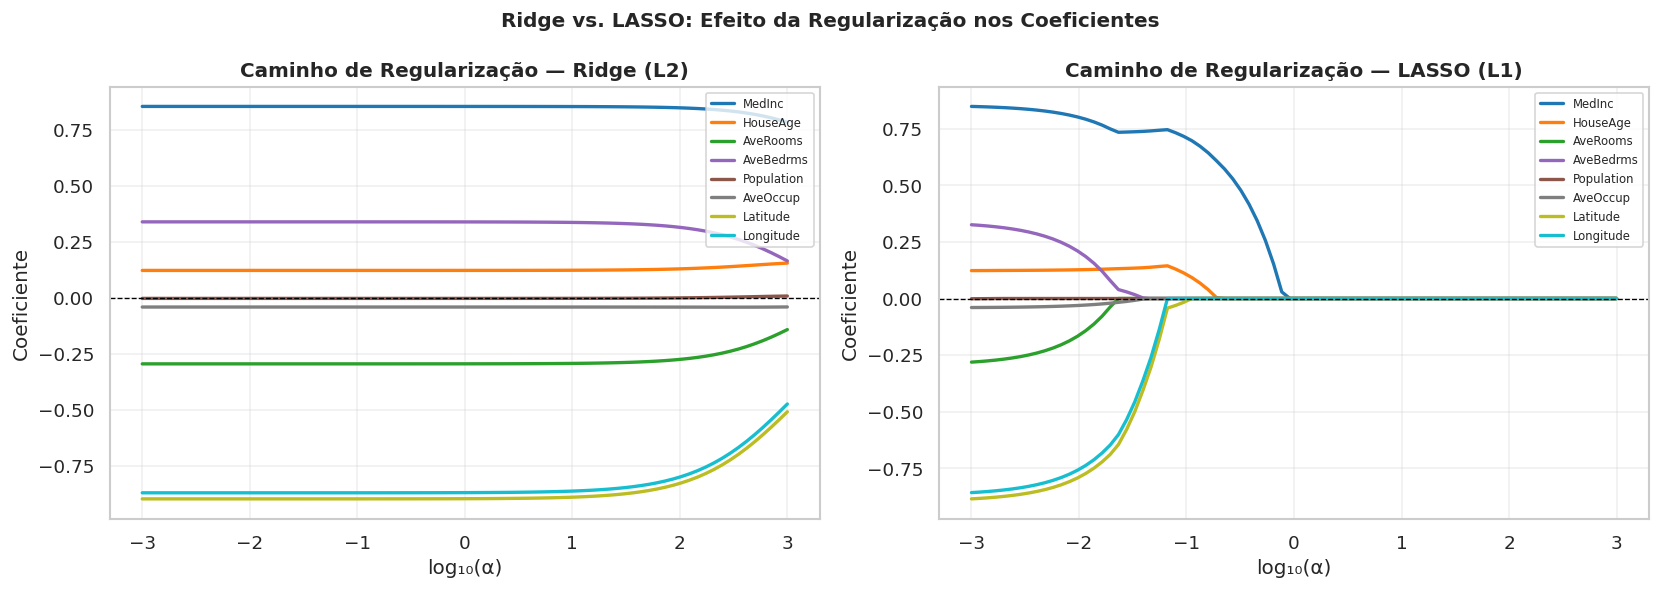

Observação: no LASSO, observe como os coeficientes são zerados sequencialmente.
No Ridge, todos os coeficientes tendem a zero mas nenhum é zerado exatamente.


In [5]:
# ── Caminho de Regularização: Ridge, LASSO e ElasticNet ─────────────────────
alphas = np.logspace(-3, 3, 80)

# Coeficientes para cada alpha
ridge_coefs = [Ridge(alpha=a).fit(X_train_sc, y_train).coef_ for a in alphas]
lasso_coefs = [Lasso(alpha=a, max_iter=5000).fit(X_train_sc, y_train).coef_ for a in alphas]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
feature_names = X.columns.tolist()
colors_feat = plt.cm.tab10(np.linspace(0, 1, len(feature_names)))

for ax, coefs, title, model_name in zip(
    axes,
    [ridge_coefs, lasso_coefs],
    ['Caminho de Regularização — Ridge (L2)', 'Caminho de Regularização — LASSO (L1)'],
    ['Ridge', 'LASSO']
):
    coefs_arr = np.array(coefs)
    for i, (feat, color) in enumerate(zip(feature_names, colors_feat)):
        ax.plot(np.log10(alphas), coefs_arr[:, i], lw=2, color=color, label=feat)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('log₁₀(α)')
    ax.set_ylabel('Coeficiente')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Ridge vs. LASSO: Efeito da Regularização nos Coeficientes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observação: no LASSO, observe como os coeficientes são zerados sequencialmente.')
print('No Ridge, todos os coeficientes tendem a zero mas nenhum é zerado exatamente.')

## ⚖️ 3. Ridge, LASSO e ElasticNet Comparados
<a id='regularization'></a>

Comparação Ridge / LASSO / ElasticNet:
                     Alpha ótimo  RMSE Teste  MAE Teste  R² Teste  Coefs ≠ 0
Ridge                     3.5565      0.7455     0.5332    0.5759        8.0
LASSO                     0.0010      0.7446     0.5331    0.5769        8.0
ElasticNet (l1=0.5)       0.0010      0.7449     0.5331    0.5765        8.0
ElasticNet (l1=0.2)       0.0010      0.7451     0.5331    0.5764        8.0


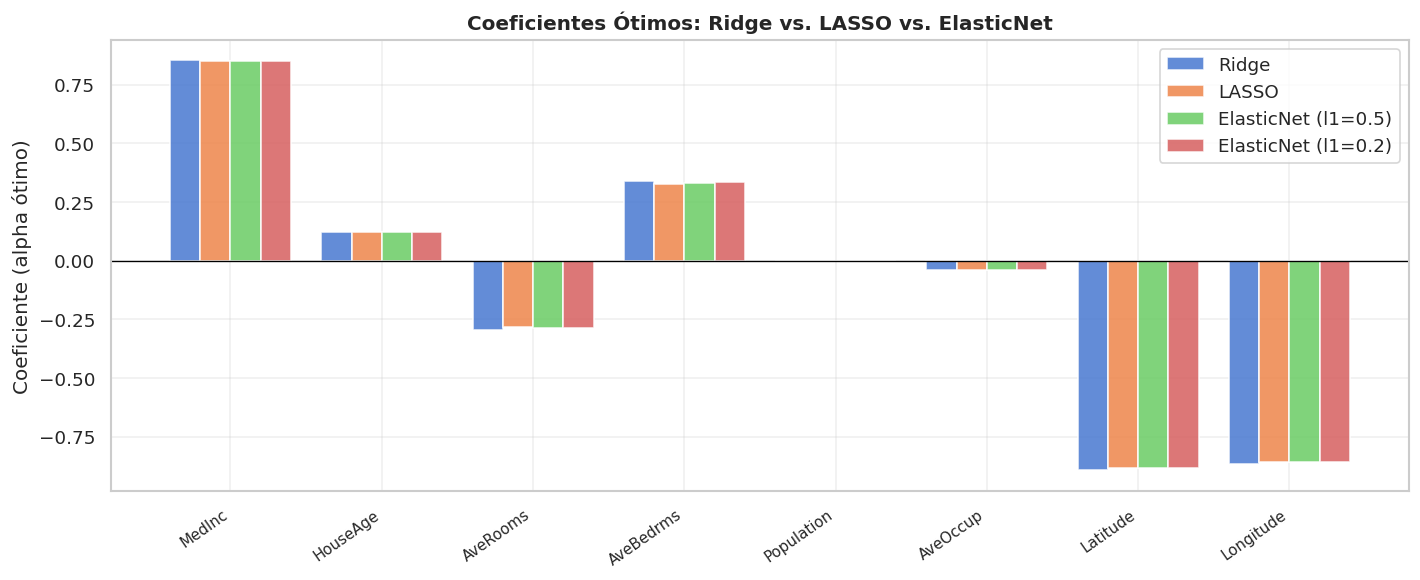

In [6]:
# ── GridSearchCV para Ridge, LASSO, ElasticNet ───────────────────────────────
from scipy.stats import uniform, loguniform

cv5 = KFold(n_splits=5, shuffle=True, random_state=SEED)
alpha_grid = {'alpha': np.logspace(-3, 3, 50)}

reg_models = {
    'Ridge': GridSearchCV(Ridge(), alpha_grid, cv=cv5, scoring='neg_root_mean_squared_error', n_jobs=-1),
    'LASSO': GridSearchCV(Lasso(max_iter=5000), alpha_grid, cv=cv5, scoring='neg_root_mean_squared_error', n_jobs=-1),
    'ElasticNet (l1=0.5)': GridSearchCV(ElasticNet(l1_ratio=0.5, max_iter=5000), alpha_grid, cv=cv5, scoring='neg_root_mean_squared_error', n_jobs=-1),
    'ElasticNet (l1=0.2)': GridSearchCV(ElasticNet(l1_ratio=0.2, max_iter=5000), alpha_grid, cv=cv5, scoring='neg_root_mean_squared_error', n_jobs=-1)
}

reg_results = {}
best_regs = {}

for name, gscv in reg_models.items():
    gscv.fit(X_train_sc, y_train)
    best_model = gscv.best_estimator_
    best_regs[name] = best_model

    y_pred = best_model.predict(X_test_sc)
    n_nonzero = np.sum(best_model.coef_ != 0)

    reg_results[name] = {
        'Alpha ótimo': gscv.best_params_['alpha'],
        'RMSE Teste': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE Teste': mean_absolute_error(y_test, y_pred),
        'R² Teste': r2_score(y_test, y_pred),
        'Coefs ≠ 0': n_nonzero
    }

df_reg = pd.DataFrame(reg_results).T
print('Comparação Ridge / LASSO / ElasticNet:')
print(df_reg.round(4).to_string())

# Gráfico de coeficientes comparados
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(feature_names))
width = 0.2
for i, (name, mdl) in enumerate(best_regs.items()):
    offset = (i - 1.5) * width
    ax.bar(x + offset, mdl.coef_, width, label=name, alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=35, ha='right', fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Coeficiente (alpha ótimo)')
ax.set_title('Coeficientes Ótimos: Ridge vs. LASSO vs. ElasticNet', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 📈 4. Regressão Polinomial e Trade-off Viés-Variância
<a id='poly'></a>

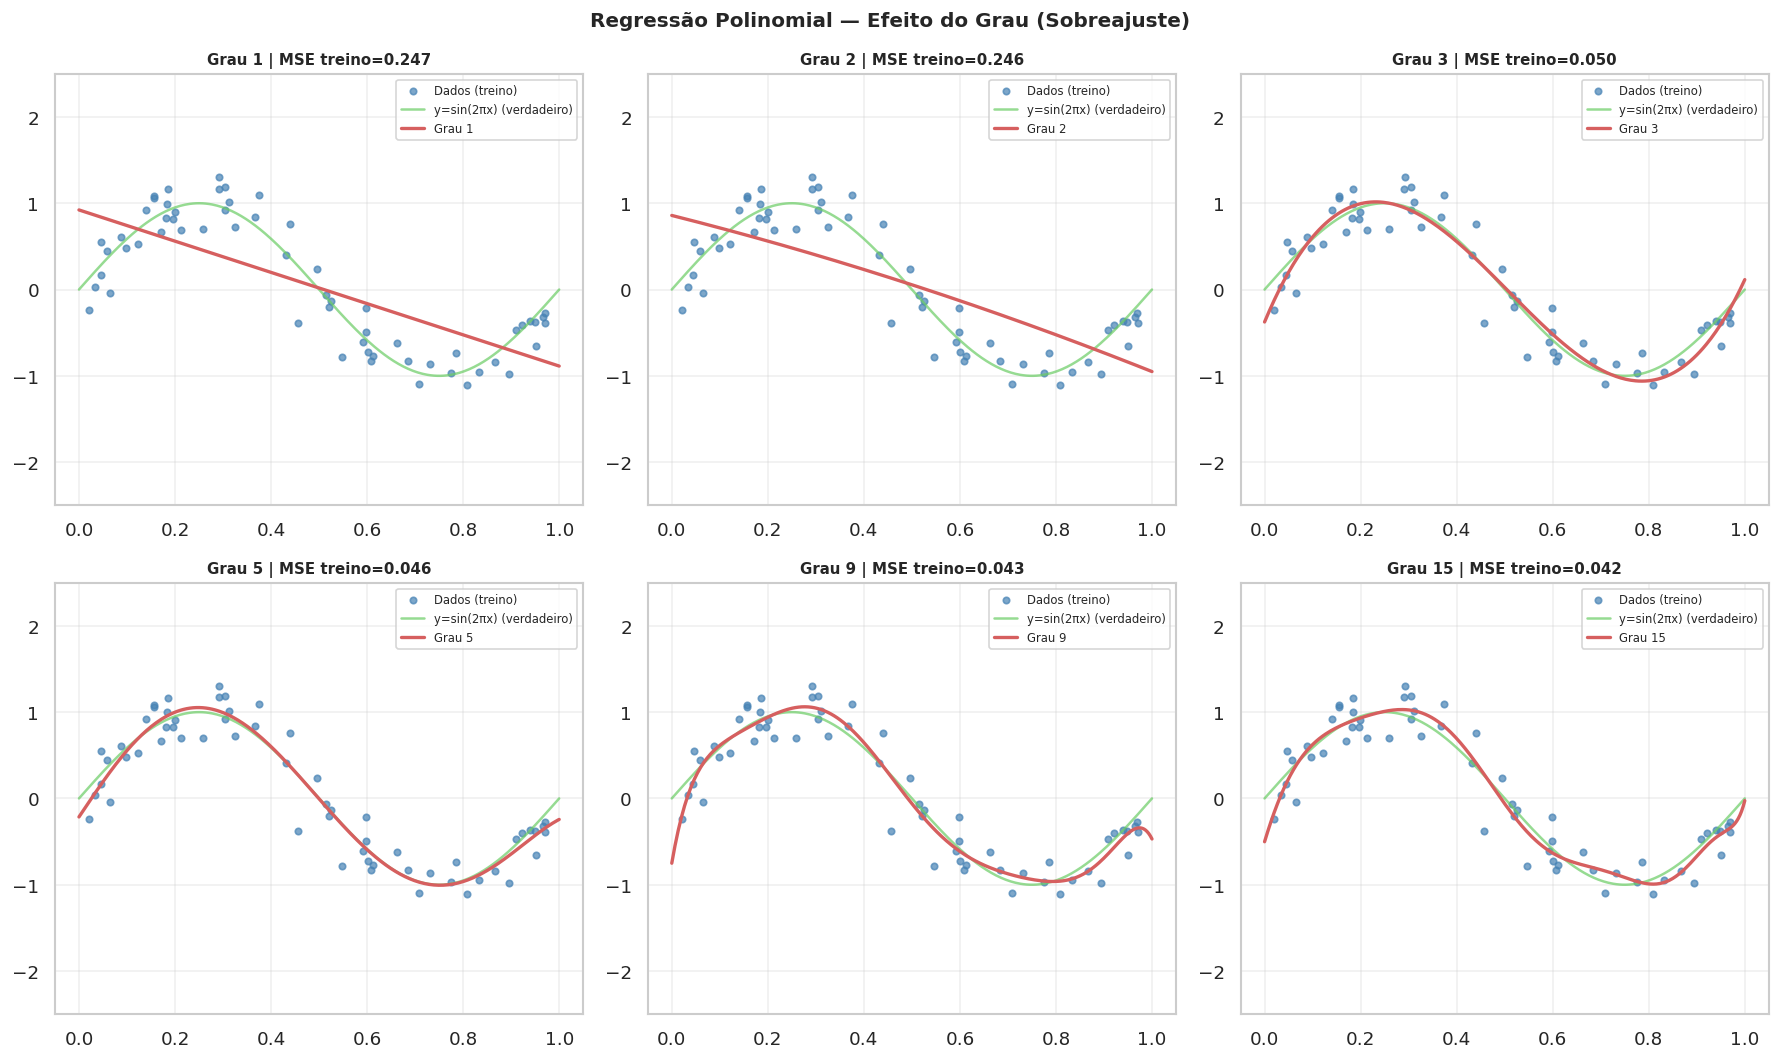

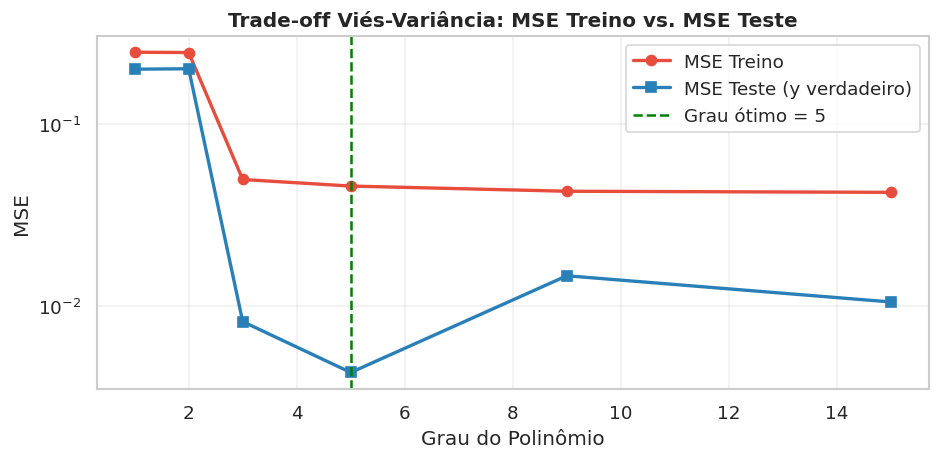

Grau ótimo: 5 (menor MSE de teste = 0.0043)


In [7]:
# ── Regressão Polinomial — Dataset 1D para visualização ──────────────────────
np.random.seed(SEED)
n_pts = 60
x_1d = np.sort(np.random.uniform(0, 1, n_pts))
y_1d = np.sin(2 * np.pi * x_1d) + np.random.normal(0, 0.25, n_pts)

# Dados de teste (densos para avaliação)
x_test_1d = np.linspace(0, 1, 300)
y_true_1d = np.sin(2 * np.pi * x_test_1d)

degrees = [1, 2, 3, 5, 9, 15]
train_mses, test_mses = [], []

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, d in zip(axes.ravel(), degrees):
    poly = PolynomialFeatures(degree=d, include_bias=False)
    lr_poly = LinearRegression()
    pipe = Pipeline([('poly', poly), ('lr', lr_poly)])
    pipe.fit(x_1d.reshape(-1, 1), y_1d)

    y_fit = pipe.predict(x_test_1d.reshape(-1, 1))
    y_train_pred = pipe.predict(x_1d.reshape(-1, 1))

    train_mse = mean_squared_error(y_1d, y_train_pred)
    test_mse  = mean_squared_error(y_true_1d, y_fit)
    train_mses.append(train_mse)
    test_mses.append(test_mse)

    ax.scatter(x_1d, y_1d, s=15, color='steelblue', alpha=0.7, label='Dados (treino)')
    ax.plot(x_test_1d, y_true_1d, 'g-', lw=1.5, label='y=sin(2πx) (verdadeiro)', alpha=0.7)
    y_fit_clipped = np.clip(y_fit, -3, 3)
    ax.plot(x_test_1d, y_fit_clipped, 'r-', lw=2, label=f'Grau {d}')
    ax.set_ylim([-2.5, 2.5])
    ax.set_title(f'Grau {d} | MSE treino={train_mse:.3f}', fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Regressão Polinomial — Efeito do Grau (Sobreajuste)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Curva Viés-Variância
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(degrees, train_mses, 'o-', color='#e74c3c', lw=2, label='MSE Treino')
ax.plot(degrees, test_mses, 's-', color='#2980b9', lw=2, label='MSE Teste (y verdadeiro)')
ax.set_xlabel('Grau do Polinômio')
ax.set_ylabel('MSE')
ax.set_title('Trade-off Viés-Variância: MSE Treino vs. MSE Teste', fontweight='bold')
ax.legend()
ax.set_yscale('log')
best_degree = degrees[np.argmin(test_mses)]
ax.axvline(best_degree, color='green', ls='--', lw=1.5, label=f'Grau ótimo = {best_degree}')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Grau ótimo: {best_degree} (menor MSE de teste = {min(test_mses):.4f})')

## 🌲 5. Random Forest para Regressão
<a id='rf'></a>

Random Forest Regressor:
  MSE: 0.2517
  RMSE: 0.5017
  MAE: 0.3242
  MAPE(%): 18.6376
  R2: 0.8079
  OOB R²: 0.8128


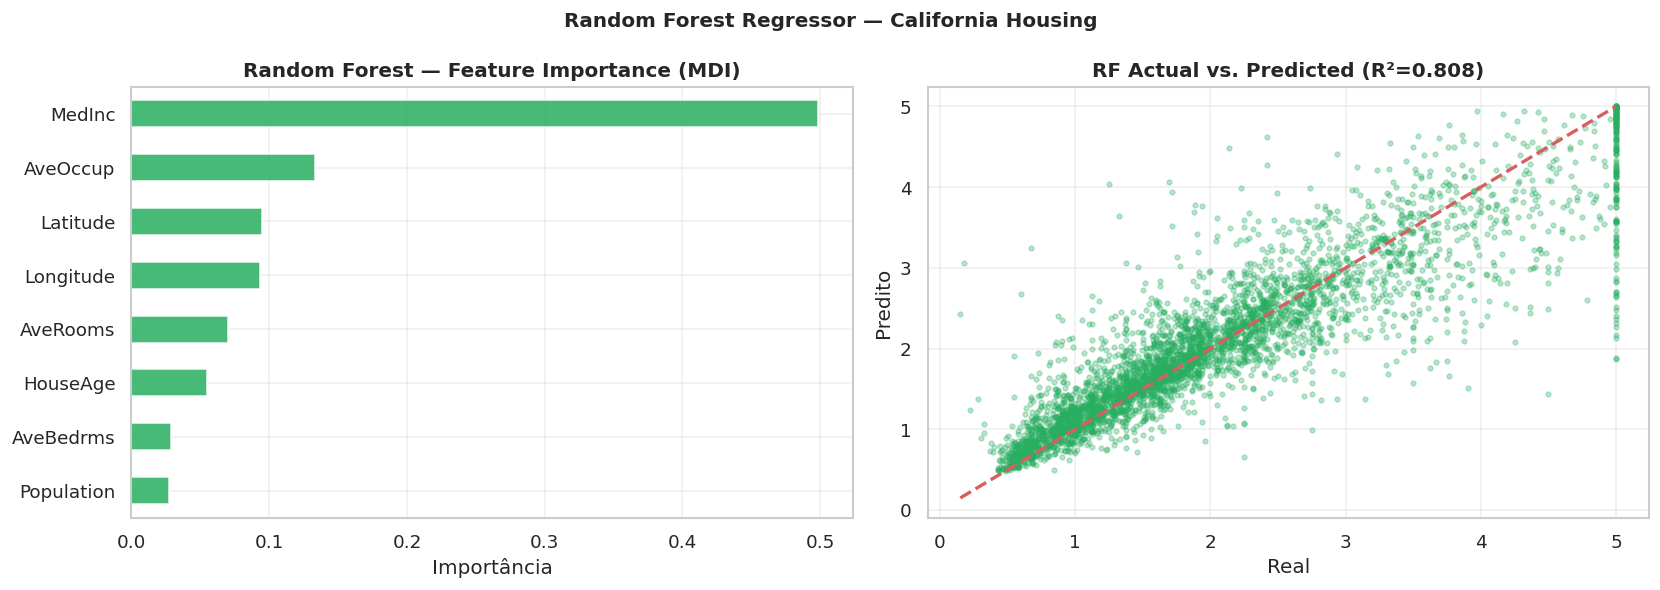


Top 3 features por importância: ['MedInc', 'AveOccup', 'Latitude']


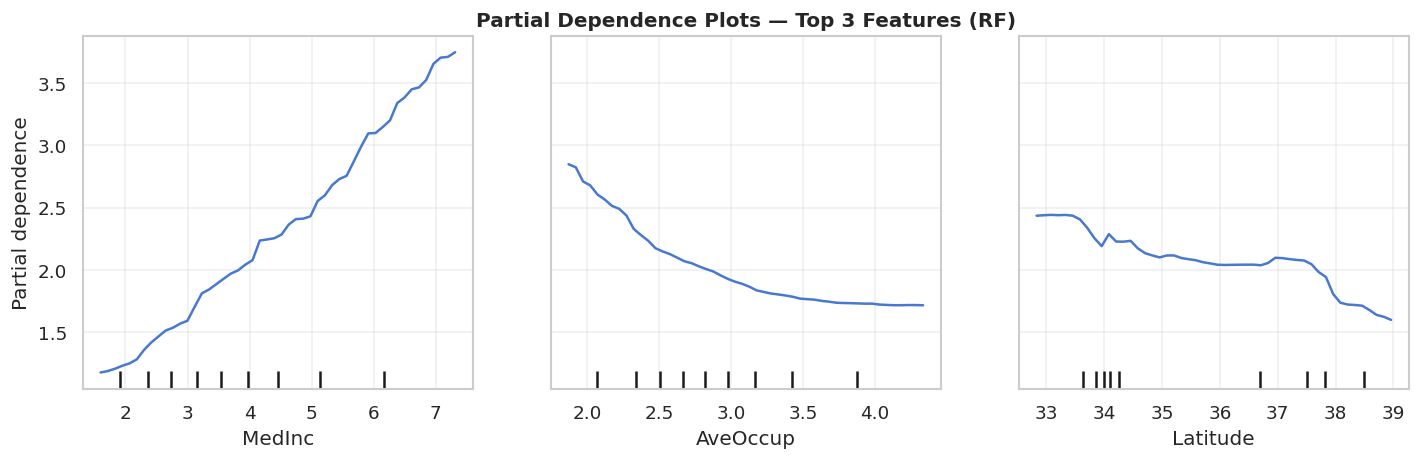

In [8]:
# ── Random Forest Regressor ───────────────────────────────────────────────────
rf_reg = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_leaf=2,
    max_features=0.8, oob_score=True, n_jobs=-1, random_state=SEED
)
rf_reg.fit(X_train, y_train)

y_pred_rf = rf_reg.predict(X_test)
metrics_rf = regression_metrics(y_test, y_pred_rf, 'Random Forest')
print('Random Forest Regressor:')
for k, v in metrics_rf.items():
    if k != 'Modelo':
        print(f'  {k}: {v:.4f}')
print(f'  OOB R²: {rf_reg.oob_score_:.4f}')

# Feature Importances
fi_rf = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fi_rf.plot(kind='barh', ax=axes[0], color='#27ae60', edgecolor='white', alpha=0.85)
axes[0].set_title('Random Forest — Feature Importance (MDI)', fontweight='bold')
axes[0].set_xlabel('Importância')

# Actual vs Predicted
axes[1].scatter(y_test, y_pred_rf, alpha=0.3, s=8, c='#27ae60')
min_v, max_v = y_test.min(), y_test.max()
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2)
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Predito')
axes[1].set_title(f'RF Actual vs. Predicted (R²={metrics_rf["R2"]:.3f})', fontweight='bold')

plt.suptitle('Random Forest Regressor — California Housing', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Partial Dependence Plots (top 3 features por importância)
top3_rf = fi_rf.nlargest(3).index.tolist()
print(f'\nTop 3 features por importância: {top3_rf}')

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    rf_reg, X_train, features=top3_rf, ax=ax,
    grid_resolution=50, kind='average'
)
ax.set_title('Partial Dependence Plots — Top 3 Features (RF)', fontweight='bold')
plt.tight_layout()
plt.show()

## ⚡ 6. XGBoost e LightGBM para Regressão + SHAP
<a id='xgb'></a>

XGBoost: RMSE=0.4513 | MAE=0.2983 | R²=0.8446
LightGBM: RMSE=0.4521 | MAE=0.2995 | R²=0.8440


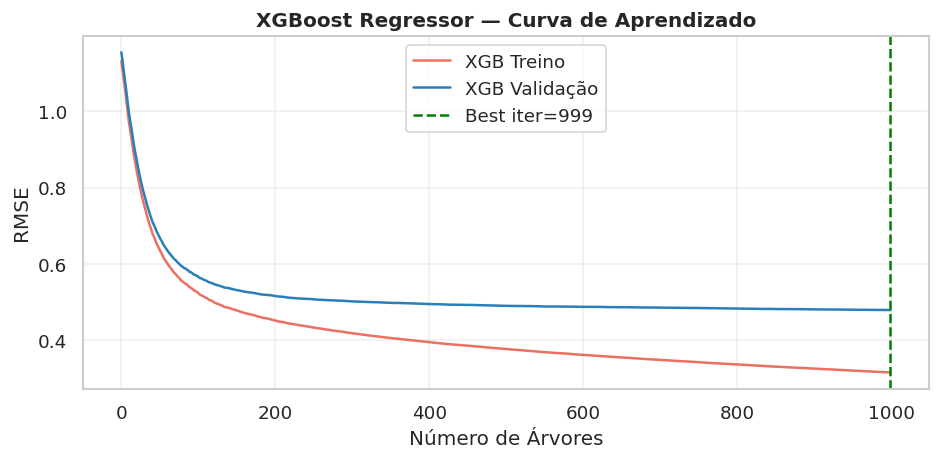

In [9]:
# ── XGBoost e LightGBM com Early Stopping ────────────────────────────────────
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED
)

# XGBoost Regressor
xgb_reg = XGBRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    early_stopping_rounds=30, eval_metric='rmse',
    random_state=SEED, verbosity=0
)
xgb_reg.fit(
    X_tr2, y_tr2,
    eval_set=[(X_tr2, y_tr2), (X_val, y_val)],
    verbose=False
)

# LightGBM Regressor
lgb_reg = LGBMRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    num_leaves=50, random_state=SEED, verbose=-1
)
lgb_reg.fit(
    X_tr2, y_tr2,
    eval_set=[(X_val, y_val)],
    callbacks=[]
)

# Resultados
for name, mdl in [('XGBoost', xgb_reg), ('LightGBM', lgb_reg)]:
    m = regression_metrics(y_test, mdl.predict(X_test), name)
    print(f'{name}: RMSE={m["RMSE"]:.4f} | MAE={m["MAE"]:.4f} | R²={m["R2"]:.4f}')

# Curva de aprendizado XGBoost
results_xgb = xgb_reg.evals_result()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_xgb['validation_0']['rmse'], label='XGB Treino', color='#e74c3c', lw=1.5, alpha=0.8)
ax.plot(results_xgb['validation_1']['rmse'], label='XGB Validação', color='#2980b9', lw=1.5)
ax.axvline(xgb_reg.best_iteration, color='green', ls='--', lw=1.5, label=f'Best iter={xgb_reg.best_iteration}')
ax.set_xlabel('Número de Árvores')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost Regressor — Curva de Aprendizado', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 📊 7. Comparação Completa de Modelos
<a id='comparison'></a>

In [ ]:
# ── Cross-Validation de 8+ Modelos ───────────────────────────────────────────
import time

all_regressors = {
    'Linear Reg.':    Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())]),
    'Ridge (opt)':    Pipeline([('sc', StandardScaler()), ('rdg', Ridge(alpha=best_regs['Ridge'].alpha))]),
    'LASSO (opt)':    Pipeline([('sc', StandardScaler()), ('ls', Lasso(alpha=best_regs['LASSO'].alpha, max_iter=5000))]),
    'ElasticNet':     Pipeline([('sc', StandardScaler()), ('en', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000))]),
    'Poly+Ridge':     Pipeline([('sc', StandardScaler()), ('poly', PolynomialFeatures(degree=2, include_bias=False)), ('rdg', Ridge(alpha=1.0))]),
    'Random Forest':  RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'XGBoost':        XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=SEED, verbosity=0),
    'LightGBM':       LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=SEED, verbose=-1)
}

cv5 = KFold(n_splits=5, shuffle=True, random_state=SEED)
comparison_data = {}

for name, mdl in all_regressors.items():
    t0 = time.time()
    rmse_cv = -cross_val_score(mdl, X_train, y_train, cv=cv5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    mae_cv  = -cross_val_score(mdl, X_train, y_train, cv=cv5, scoring='neg_mean_absolute_error', n_jobs=-1)
    r2_cv   =  cross_val_score(mdl, X_train, y_train, cv=cv5, scoring='r2', n_jobs=-1)
    tempo   = time.time() - t0

    mdl.fit(X_train, y_train)
    y_pred = mdl.predict(X_test)

    comparison_data[name] = {
        'RMSE CV':    rmse_cv.mean(),
        'RMSE std':   rmse_cv.std(),
        'MAE CV':     mae_cv.mean(),
        'R² CV':      r2_cv.mean(),
        'RMSE Teste': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R² Teste':   r2_score(y_test, y_pred),
        'Tempo(s)':   tempo
    }

df_comp = pd.DataFrame(comparison_data).T.sort_values('RMSE CV')
print('Comparação Completa — 5-Fold CV + Teste (ordenado por RMSE CV):')
print(df_comp.round(4).to_string())

# Gráfico de barras com barras de erro
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = df_comp.index.tolist()
rmses = df_comp['RMSE CV'].values
stds  = df_comp['RMSE std'].values
r2s   = df_comp['R² Teste'].values

bars = axes[0].bar(names, rmses, yerr=stds, capsize=5, color='#2980b9', edgecolor='white', alpha=0.85)
axes[0].set_title('RMSE (CV) com Intervalo de Confiança', fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=40, labelsize=8)

bars2 = axes[1].bar(names, r2s, color='#27ae60', edgecolor='white', alpha=0.85)
axes[1].set_title('R² no Conjunto de Teste', fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=40, labelsize=8)
for bar, val in zip(bars2, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Comparação de Modelos de Regressão — California Housing', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Actual vs. Predicted — Grid para todos os modelos ─────────────────────────
n_models = len(all_regressors)
ncols = 4
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes_flat = axes.ravel()

for i, (name, mdl) in enumerate(all_regressors.items()):
    ax = axes_flat[i]
    y_pred_i = mdl.predict(X_test)
    r2_i = r2_score(y_test, y_pred_i)
    rmse_i = np.sqrt(mean_squared_error(y_test, y_pred_i))

    # Destaque: verde para melhor, vermelho para pior
    color = '#27ae60' if i == 0 else ('#e74c3c' if i == n_models - 1 else '#2980b9')

    ax.scatter(y_test, y_pred_i, alpha=0.3, s=6, c=color)
    lo, hi = y_test.min(), y_test.max()
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5)
    ax.set_xlabel('Real', fontsize=8)
    ax.set_ylabel('Predito', fontsize=8)
    ax.set_title(f'{name}\nR²={r2_i:.3f} | RMSE={rmse_i:.3f}', fontsize=8, fontweight='bold')

# Remover eixos extras
for j in range(n_models, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Actual vs. Predicted — Todos os Modelos\n(verde=melhor, vermelho=pior por RMSE CV)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 🔮 8. Análise de Erros
<a id='error-analysis'></a>

In [ ]:
# ── Análise de Erros — Melhor Modelo ─────────────────────────────────────────
best_model_name = df_comp.index[0]  # modelo com menor RMSE CV
best_mdl = all_regressors[best_model_name]
y_pred_best = best_mdl.predict(X_test)
errors_best = y_test.values - y_pred_best
abs_errors  = np.abs(errors_best)

print(f'Análise de Erros — Melhor Modelo: {best_model_name}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred_best):.4f}')
print(f'  Max Erro Absoluto: {abs_errors.max():.4f}')
print(f'  Percentil 90 do erro: {np.percentile(abs_errors, 90):.4f}')

# Piores predições
worst_idx = np.argsort(abs_errors)[-10:]
print(f'\n10 Piores Predições:')
worst_df = X_test.iloc[worst_idx].copy()
worst_df['Real'] = y_test.values[worst_idx]
worst_df['Predito'] = y_pred_best[worst_idx]
worst_df['Erro'] = errors_best[worst_idx]
worst_df['|Erro|'] = abs_errors[worst_idx]
print(worst_df[['MedInc', 'HouseAge', 'AveOccup', 'Real', 'Predito', 'Erro', '|Erro|']].round(3).to_string())

# Resíduos coloridos por feature
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

features_to_check = ['MedInc', 'HouseAge', 'AveOccup', 'AveRooms']
for ax, feat in zip(axes.ravel(), features_to_check):
    sc = ax.scatter(
        y_pred_best, errors_best,
        c=X_test[feat].values, cmap='coolwarm',
        alpha=0.4, s=8
    )
    plt.colorbar(sc, ax=ax, label=feat)
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.set_xlabel('Valor Predito')
    ax.set_ylabel('Resíduo')
    ax.set_title(f'Resíduos coloridos por {feat}', fontweight='bold', fontsize=9)

plt.suptitle(f'Análise de Erros — {best_model_name}\n(Padrões nos resíduos indicam violações do modelo)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔢 9. Predição com Intervalo de Confiança (Regressão Quantílica)
<a id='intervals'></a>

In [ ]:
# ── Regressão Quantílica com LightGBM ────────────────────────────────────────
# Predizemos os percentis 5%, 50% e 95%
quantiles = [0.05, 0.5, 0.95]
quantile_models = {}

for q in quantiles:
    lgb_q = LGBMRegressor(
        objective='quantile', alpha=q,
        n_estimators=200, learning_rate=0.05,
        max_depth=5, random_state=SEED, verbose=-1
    )
    lgb_q.fit(X_train, y_train)
    quantile_models[q] = lgb_q

# Predições
y_pred_low  = quantile_models[0.05].predict(X_test)
y_pred_med  = quantile_models[0.50].predict(X_test)
y_pred_high = quantile_models[0.95].predict(X_test)

# Cobertura empírica (intervalo [P5, P95] deveria cobrir ~90% dos valores)
covered = np.mean((y_test.values >= y_pred_low) & (y_test.values <= y_pred_high))
width   = np.mean(y_pred_high - y_pred_low)

print('Regressão Quantílica — LightGBM:')
print(f'  Cobertura empírica [P5, P95]: {covered*100:.1f}% (objetivo: 90%)')
print(f'  Largura média do intervalo:   {width:.4f} (100k USD)')

# Visualização: plotar com intervalo de predição (amostra ordenada)
sample_idx = np.argsort(y_test.values)[:150]  # 150 pontos ordenados pelo valor real
x_plot = np.arange(len(sample_idx))

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(
    x_plot,
    y_pred_low[sample_idx],
    y_pred_high[sample_idx],
    alpha=0.3, color='#3498db', label='Intervalo [P5, P95]'
)
ax.plot(x_plot, y_pred_med[sample_idx], '-', color='#2980b9', lw=1.5, label='Mediana predita (P50)')
ax.scatter(x_plot, y_test.values[sample_idx], s=12, color='#e74c3c', alpha=0.7, label='Valor real', zorder=5)
ax.set_xlabel('Amostras (ordenadas por valor real)')
ax.set_ylabel('Valor Mediano da Casa (100k USD)')
ax.set_title(f'Predição com Intervalo de Confiança 90% — Regressão Quantílica (LightGBM)\n'
             f'Cobertura empírica: {covered*100:.1f}% | Largura média: {width:.3f}',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Tentativa de calibração com MAPIE
try:
    from mapie.regression import MapieRegressor
    mapie = MapieRegressor(
        estimator=LGBMRegressor(n_estimators=100, random_state=SEED, verbose=-1),
        method='base',
        cv=5
    )
    mapie.fit(X_train, y_train)
    y_pred_mapie, y_pis = mapie.predict(X_test, alpha=0.10)  # 90% de cobertura

    covered_mapie = np.mean(
        (y_test.values >= y_pis[:, 0, 0]) &
        (y_test.values <= y_pis[:, 1, 0])
    )
    print(f'\nMAPIE (Predição Conformal, 90% nominal):')
    print(f'  Cobertura empírica: {covered_mapie*100:.1f}%')
    print(f'  Largura média do intervalo: {np.mean(y_pis[:,1,0] - y_pis[:,0,0]):.4f}')
except ImportError:
    print('\nMAPIE não disponível. Instale com: !pip install mapie')
    print('MAPIE implementa Predição Conformal com garantias estatísticas de cobertura.')

## 🎓 10. Exercícios Práticos
<a id='exercises'></a>

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# EXERCÍCIO 1: Cálculo manual de OLS
# ══════════════════════════════════════════════════════════════════════════════
print('EXERCÍCIO 1 — OLS Manual')
print('=' * 60)

# Dataset de exemplo: preço de casas (simplificado)
x_ex = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_ex = np.array([2.5, 4.1, 5.8, 7.2, 9.0])

x_bar = x_ex.mean()
y_bar = y_ex.mean()

beta1_hat = np.sum((x_ex - x_bar) * (y_ex - y_bar)) / np.sum((x_ex - x_bar)**2)
beta0_hat = y_bar - beta1_hat * x_bar

y_pred_ex  = beta0_hat + beta1_hat * x_ex
ss_res = np.sum((y_ex - y_pred_ex)**2)
ss_tot = np.sum((y_ex - y_bar)**2)
r2_ex  = 1 - ss_res / ss_tot
rmse_ex = np.sqrt(np.mean((y_ex - y_pred_ex)**2))

print(f'beta_0 (intercepto): {beta0_hat:.4f}')
print(f'beta_1 (inclinação): {beta1_hat:.4f}')
print(f'Modelo: y = {beta0_hat:.4f} + {beta1_hat:.4f} * x')
print(f'R²: {r2_ex:.4f}')
print(f'RMSE: {rmse_ex:.4f}')
print()
print('Interpretação:')
print(f'  Para cada unidade a mais em x, y aumenta em {beta1_hat:.4f} unidades (ceteris paribus).')

# Verificação com scikit-learn
lr_check = LinearRegression().fit(x_ex.reshape(-1, 1), y_ex)
print(f'\nVerificação scikit-learn: beta_0={lr_check.intercept_:.4f}, beta_1={lr_check.coef_[0]:.4f}')

# ══════════════════════════════════════════════════════════════════════════════
# EXERCÍCIO 2: RMSE vs. MAE — Quando usar cada um?
# ══════════════════════════════════════════════════════════════════════════════
print('\nEXERCÍCIO 2 — RMSE vs. MAE')
print('=' * 60)

# Simulação com outliers
np.random.seed(SEED)
y_true_ex2 = np.concatenate([np.random.normal(5, 1, 90), np.array([20, 25, 18, 22, 19, 24, 21, 23, 17, 26])])
y_pred_ex2 = np.full_like(y_true_ex2, y_true_ex2.mean())

rmse_ex2 = np.sqrt(mean_squared_error(y_true_ex2, y_pred_ex2))
mae_ex2  = mean_absolute_error(y_true_ex2, y_pred_ex2)

print(f'Dataset com 10% de outliers extremos:')
print(f'  RMSE: {rmse_ex2:.4f} (fortemente influenciado pelos outliers)')
print(f'  MAE:  {mae_ex2:.4f}  (mais robusto aos outliers)')
print()
print('Quando usar RMSE: quando erros grandes são muito custosos (ex: previsão de demanda crítica).')
print('Quando usar MAE: quando outliers são esperados e não devem dominar a otimização.')

# ══════════════════════════════════════════════════════════════════════════════
# EXERCÍCIO 3: Tuning XGBoost Regressor
# ══════════════════════════════════════════════════════════════════════════════
print('\nEXERCÍCIO 3 — Tuning XGBoost Regressor com RandomizedSearchCV')
print('=' * 60)

from scipy.stats import randint, uniform as sp_uniform

param_dist_xgb_reg = {
    'n_estimators':    randint(100, 400),
    'max_depth':       randint(3, 8),
    'learning_rate':   sp_uniform(0.01, 0.19),
    'subsample':       sp_uniform(0.6, 0.4),
    'colsample_bytree':sp_uniform(0.6, 0.4),
    'reg_alpha':       sp_uniform(0, 1),
    'reg_lambda':      sp_uniform(0.5, 2)
}

xgb_tune_reg = XGBRegressor(random_state=SEED, verbosity=0)
rscv = RandomizedSearchCV(
    xgb_tune_reg, param_dist_xgb_reg, n_iter=20,
    cv=KFold(5, shuffle=True, random_state=SEED),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=SEED
)
rscv.fit(X_train, y_train)

print('Melhores Hiperparâmetros (XGBoost Regressor):')
for k, v in rscv.best_params_.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')
best_xgb_tuned = rscv.best_estimator_
rmse_tuned = np.sqrt(mean_squared_error(y_test, best_xgb_tuned.predict(X_test)))
r2_tuned   = r2_score(y_test, best_xgb_tuned.predict(X_test))
print(f'\nRMSE Teste (tuned): {rmse_tuned:.4f}')
print(f'R² Teste (tuned):   {r2_tuned:.4f}')